# Projet Final — Prédiction des Maladies Cardiaques

**Jedha Bootcamp — Data Essentials**  
**Flavien, Gabriel, Saïd — Mars 2026**

---

## Step 1 — Importation des librairies

On importe toutes les librairies nécessaires au projet :
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisation
- **sklearn** : modèles de Machine Learning, prétraitement et évaluation

In [3]:
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn : Séparation train/test ───────────────────
from sklearn.model_selection import train_test_split

# ── Sklearn : Prétraitement ───────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Sklearn : Modèles ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Sklearn : Évaluation ──────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, recall_score
import warnings
warnings.filterwarnings('ignore')


## Step 2 — Chargement et aperçu du dataset

Le dataset provient de 5 sources de données cardiaques fusionnées (Cleveland, Hongrie, Suisse, Long Beach, Stalog).  
Au total : **918 observations** et **12 colonnes** (11 features + 1 variable cible `HeartDisease`).

In [4]:
df = pd.read_excel('/home/gabriel/Bureau/VisualStudioCode/Projet Essentiels JEDHA/dataset/DataSet_heart.xlsx')

print("Dimension du dataset:", df.shape)

print("### Aperçu des premières lignes du dataset ###\n")
print(df.head())

print("\n\n### Statistiques descriptives du dataset ###\n")
print(df.describe(include="all"))


Dimension du dataset: (918, 12)
### Aperçu des premières lignes du dataset ###

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40   M           ATA        140          289          0           0   
1   49   F           NAP        160          180          0           0   
2   37   M           ATA        130          283          0           1   
3   48   F           ASY        138          214          0           0   
4   54   M           NAP        150          195          0           0   

   MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease (Maladie)  
0    172              N      0.0       Up                       0  
1    156              N      1.0     Flat                       1  
2     98              N      0.0       Up                       0  
3    108              Y      1.5     Flat                       1  
4    122              N      0.0       Up                       0  


### Statistiques descriptives du dataset ###

             

## Step 3 — Nettoyage des données

On vérifie les valeurs manquantes et les erreurs de saisie.  
Le cholestérol et la pression artérielle à **0** sont médicalement impossibles : on les remplace par `NaN` pour les traiter ensuite via imputation (médiane).

In [5]:
# Renommage de la cible pour plus de simplicité
df = df.rename(columns={'HeartDisease (Maladie)': 'HeartDisease'})

# Vérification des cellules vides
print("Valeurs manquantes par colonne :\n\n", df.isnull().sum())

### TRAITEMENT DES ERREURS DE SAISIE ###
# Le cholestérol et la tension (RestingBP) à 0 sont médicalement impossibles.
# On les marque comme manquants (NaN) pour les traiter plus tard.

print(f"\nNombre de zéros en Cholestérol : {(df['Cholesterol'] == 0).sum()}")
print(f"Nombre de zéros en RestingBP   : {(df['RestingBP'] == 0).sum()}")

# Remplacement des 0 par NaN
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP']   = df['RestingBP'].replace(0, np.nan)

print("\n✅ ...Nettoyage terminé. Les zéros ont été remplacés par des valeurs nulles.")


Valeurs manquantes par colonne :

 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Nombre de zéros en Cholestérol : 172
Nombre de zéros en RestingBP   : 1

✅ ...Nettoyage terminé. Les zéros ont été remplacés par des valeurs nulles.


## Step 4 — Analyse Exploratoire (EDA)

Avant de modéliser, on explore les données visuellement pour comprendre la répartition de la variable cible, l'influence de chaque variable et les corrélations.

### 4.1 — Distribution de la variable cible

On regarde si le dataset est équilibré entre patients sains (0) et malades (1). Un dataset équilibré est important pour que le modèle n'apprenne pas à prédire toujours la même classe.

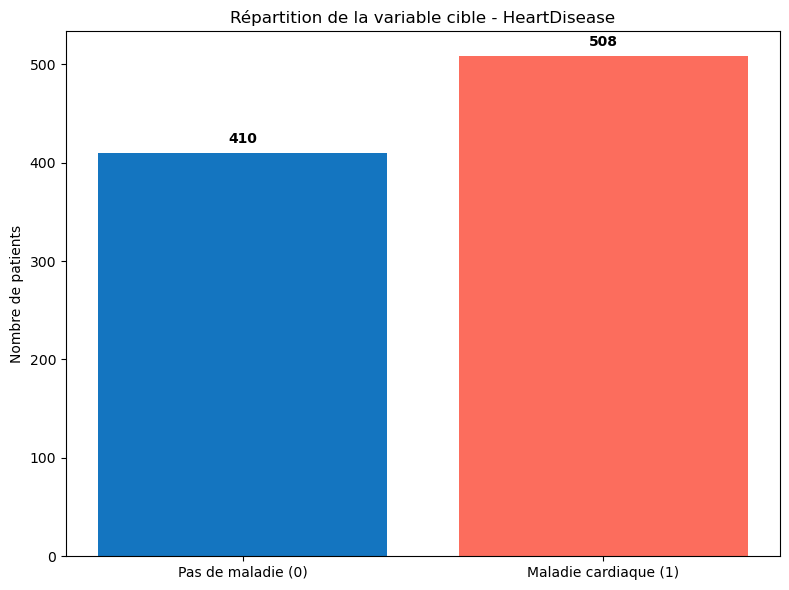


Proportion : 55.3% malades vs 44.7% sains

Le dataset est relativement equilibre, c'est bien pour l'entrainement.


In [6]:
# - La répartition de la variable cible (équilibrée ou non ?)
# - L'influence de chaque variable sur la maladie cardiaque
# - Les corrélations entre variables numériques

#############################################
### 4.1 Distribution de la variable cible ###
#############################################

fig, ax = plt.subplots(figsize=(8, 6))
counts = df['HeartDisease'].value_counts().sort_index()  # sort_index() pour avoir 0 puis 1
ax.bar(['Pas de maladie (0)', 'Maladie cardiaque (1)'], counts.values, 
       color=["#1475c0", "#fc6d5d"])
ax.set_ylabel('Nombre de patients')
ax.set_title('Répartition de la variable cible - HeartDisease')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nProportion : {counts[1]/len(df)*100:.1f}% malades vs {counts[0]/len(df)*100:.1f}% sains\n")
print("Le dataset est relativement equilibre, c'est bien pour l'entrainement.")

### 4.2 — Distribution par sexe et par âge

On croise le sexe et l'âge avec la variable cible pour identifier les populations les plus à risque.

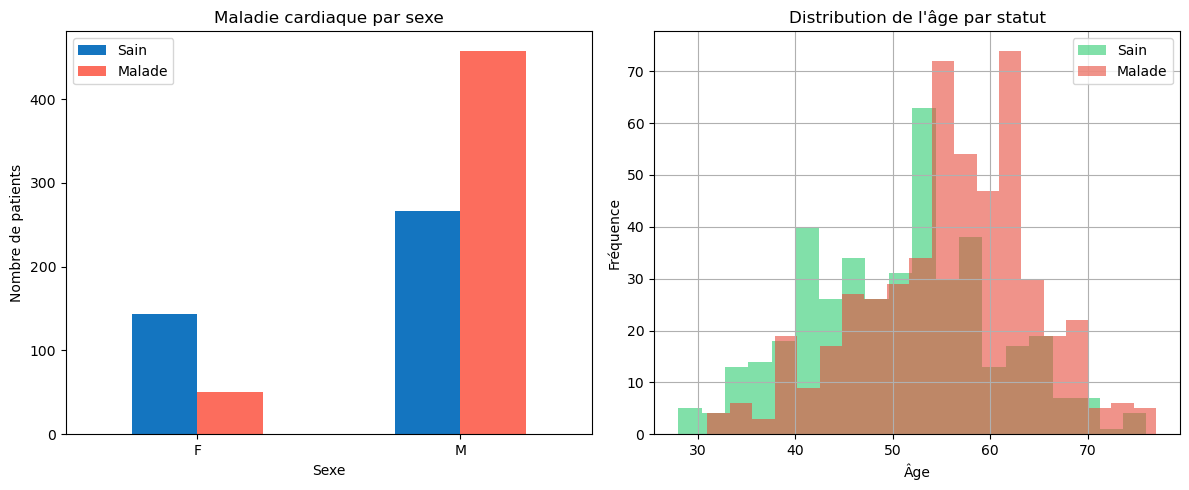

On observe que les hommes sont beaucoup plus touches que les femmes dans ce dataset.

Les patients malades sont en moyenne plus ages.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sexe vs HeartDisease
ct_sex = pd.crosstab(df['Sex'], df['HeartDisease'])
ct_sex.plot(kind='bar', ax=axes[0], color=['#1475c0', "#fc6d5d"])
axes[0].set_title('Maladie cardiaque par sexe')
axes[0].set_xlabel('Sexe')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend(['Sain', 'Malade'])
axes[0].tick_params(axis='x', rotation=0)

# Age distribution par statut
df[df['HeartDisease']==0]['Age'].hist(bins=20, alpha=0.6, label='Sain', color='#2ecc71', ax=axes[1])
df[df['HeartDisease']==1]['Age'].hist(bins=20, alpha=0.6, label='Malade', color='#e74c3c', ax=axes[1])
axes[1].set_title("Distribution de l'âge par statut")
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

print("On observe que les hommes sont beaucoup plus touches que les femmes dans ce dataset.\n")
print("Les patients malades sont en moyenne plus ages.")

### 4.3 — Moyenne des variables numériques par statut cardiaque

On compare la **valeur moyenne** de chaque variable numérique entre patients sains (0) et malades (1).  
Un diagramme en bâtons groupé permet de voir immédiatement quelles variables diffèrent le plus entre les deux groupes.

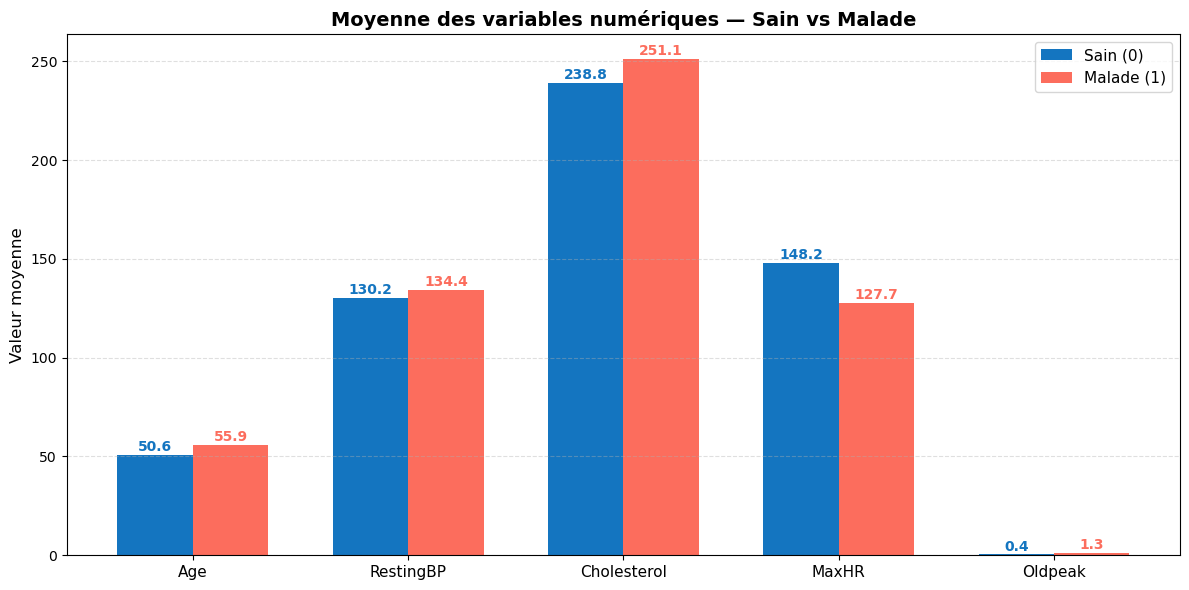

Points clés :
- MaxHR est plus bas chez les patients malades (le coeur fatigue)
- Oldpeak est plus élevé chez les malades (signe de stress cardiaque)
- L'âge est légèrement plus élevé chez les malades


In [8]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Calcul des moyennes par statut cardiaque
moyennes_sain   = df[df['HeartDisease'] == 0][numeric_cols].mean()
moyennes_malade = df[df['HeartDisease'] == 1][numeric_cols].mean()

x = np.arange(len(numeric_cols))
largeur = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - largeur/2, moyennes_sain,   largeur, label='Sain (0)',   color='#1475c0')
bars2 = ax.bar(x + largeur/2, moyennes_malade,  largeur, label='Malade (1)', color='#fc6d5d')

# Valeurs au-dessus des barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold', color='#1475c0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold', color='#fc6d5d')

ax.set_ylabel('Valeur moyenne', fontsize=12)
ax.set_title('Moyenne des variables numériques — Sain vs Malade', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Points clés :")
print("- MaxHR est plus bas chez les patients malades (le coeur fatigue)")
print("- Oldpeak est plus élevé chez les malades (signe de stress cardiaque)")
print("- L'âge est légèrement plus élevé chez les malades")

### 4.4 — Type de douleur thoracique vs maladie cardiaque

**ASY** (asymptomatique) est paradoxalement le type le plus associé à la maladie cardiaque : les patients les plus malades n'ont parfois aucune douleur visible.

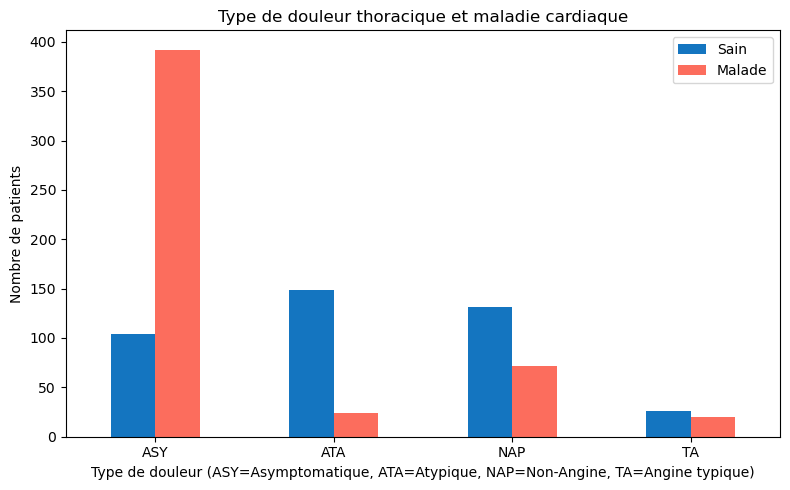

ASY (asymptomatique) est le plus souvent associe a la maladie cardiaque.
C'est contre-intuitif : les patients les plus malades n'ont parfois PAS de douleur visible.


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ct_chest = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
ct_chest.plot(kind='bar', ax=ax, color=['#1475c0', '#fc6d5d'])
ax.set_title('Type de douleur thoracique et maladie cardiaque')
ax.set_xlabel('Type de douleur (ASY=Asymptomatique, ATA=Atypique, NAP=Non-Angine, TA=Angine typique)')
ax.set_ylabel('Nombre de patients')
ax.legend(['Sain', 'Malade'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("ASY (asymptomatique) est le plus souvent associe a la maladie cardiaque.")
print("C'est contre-intuitif : les patients les plus malades n'ont parfois PAS de douleur visible.")

### 4.5 — ExerciseAngina, FastingBS et ST_Slope vs maladie cardiaque

Ces 3 variables catégorielles sont parmi les plus influentes dans nos modèles :
- **ExerciseAngina** : le patient ressent-il une douleur thoracique à l'effort ?
- **FastingBS** : la glycémie à jeun est-elle élevée (> 120 mg/dl) ?
- **ST_Slope** : la pente du segment ST à l'électrocardiogramme (Up = bonne santé, Flat/Down = signal d'alarme)

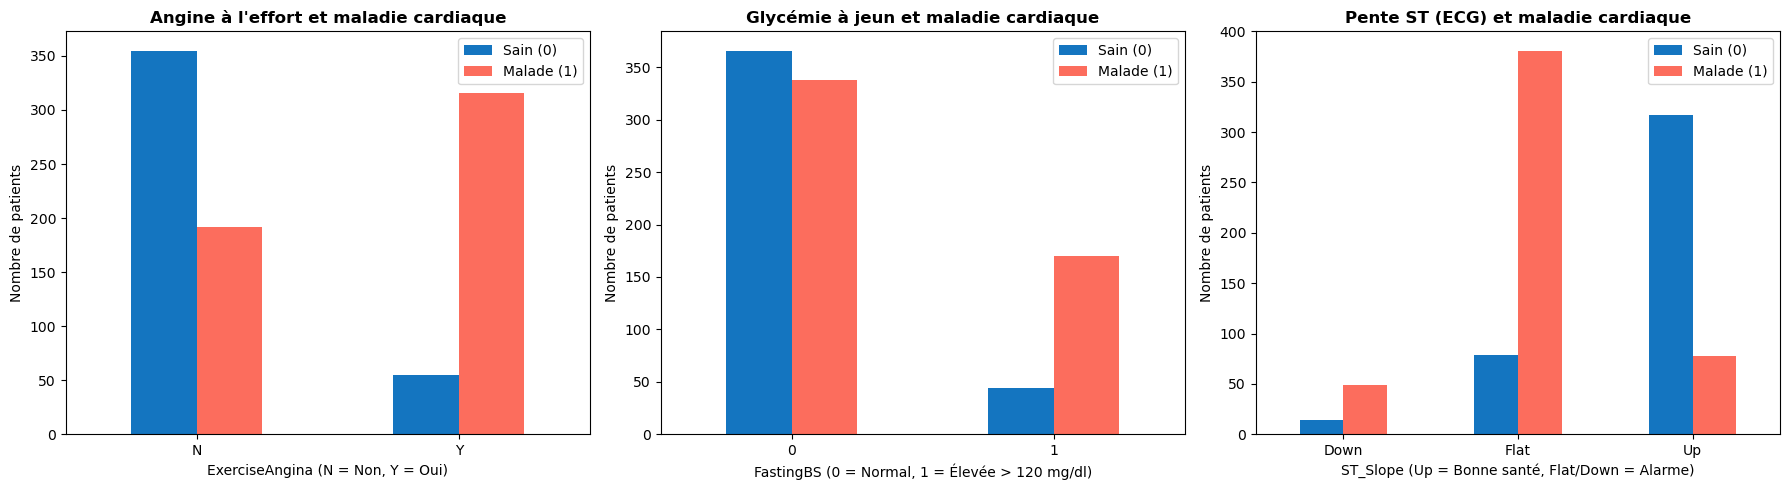

Points clés :
- ExerciseAngina : les patients avec angine à l'effort (Y) sont majoritairement malades
- FastingBS : une glycémie élevée (1) augmente le risque de maladie cardiaque
- ST_Slope : 'Up' est un signe de bonne santé, 'Flat' est fortement associé à la maladie


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

###################################
### ExerciseAngina vs HeartDisease
###################################
ct_angina = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
ct_angina.plot(kind='bar', ax=axes[0], color=['#1475c0', '#fc6d5d'])
axes[0].set_title('Angine à l\'effort et maladie cardiaque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ExerciseAngina (N = Non, Y = Oui)')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend(['Sain (0)', 'Malade (1)'])
axes[0].tick_params(axis='x', rotation=0)

###################################
### FastingBS vs HeartDisease
###################################
ct_fbs = pd.crosstab(df['FastingBS'], df['HeartDisease'])
ct_fbs.plot(kind='bar', ax=axes[1], color=['#1475c0', '#fc6d5d'])
axes[1].set_title('Glycémie à jeun et maladie cardiaque', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FastingBS (0 = Normal, 1 = Élevée > 120 mg/dl)')
axes[1].set_ylabel('Nombre de patients')
axes[1].legend(['Sain (0)', 'Malade (1)'])
axes[1].tick_params(axis='x', rotation=0)

###################################
### ST_Slope vs HeartDisease
###################################
ct_slope = pd.crosstab(df['ST_Slope'], df['HeartDisease'])
ct_slope.plot(kind='bar', ax=axes[2], color=['#1475c0', '#fc6d5d'])
axes[2].set_title('Pente ST (ECG) et maladie cardiaque', fontsize=12, fontweight='bold')
axes[2].set_xlabel('ST_Slope (Up = Bonne santé, Flat/Down = Alarme)')
axes[2].set_ylabel('Nombre de patients')
axes[2].legend(['Sain (0)', 'Malade (1)'])
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Points clés :")
print("- ExerciseAngina : les patients avec angine à l'effort (Y) sont majoritairement malades")
print("- FastingBS : une glycémie élevée (1) augmente le risque de maladie cardiaque")
print("- ST_Slope : 'Up' est un signe de bonne santé, 'Flat' est fortement associé à la maladie")

### 4.6 — Matrice de corrélation complète

On encode toutes les variables catégorielles (avec `get_dummies`) pour calculer la corrélation entre **toutes** les variables, y compris ST_Slope, ChestPainType, etc.  
C'est cette matrice qui permet de justifier l'importance de variables comme ST_Slope dans la prédiction.

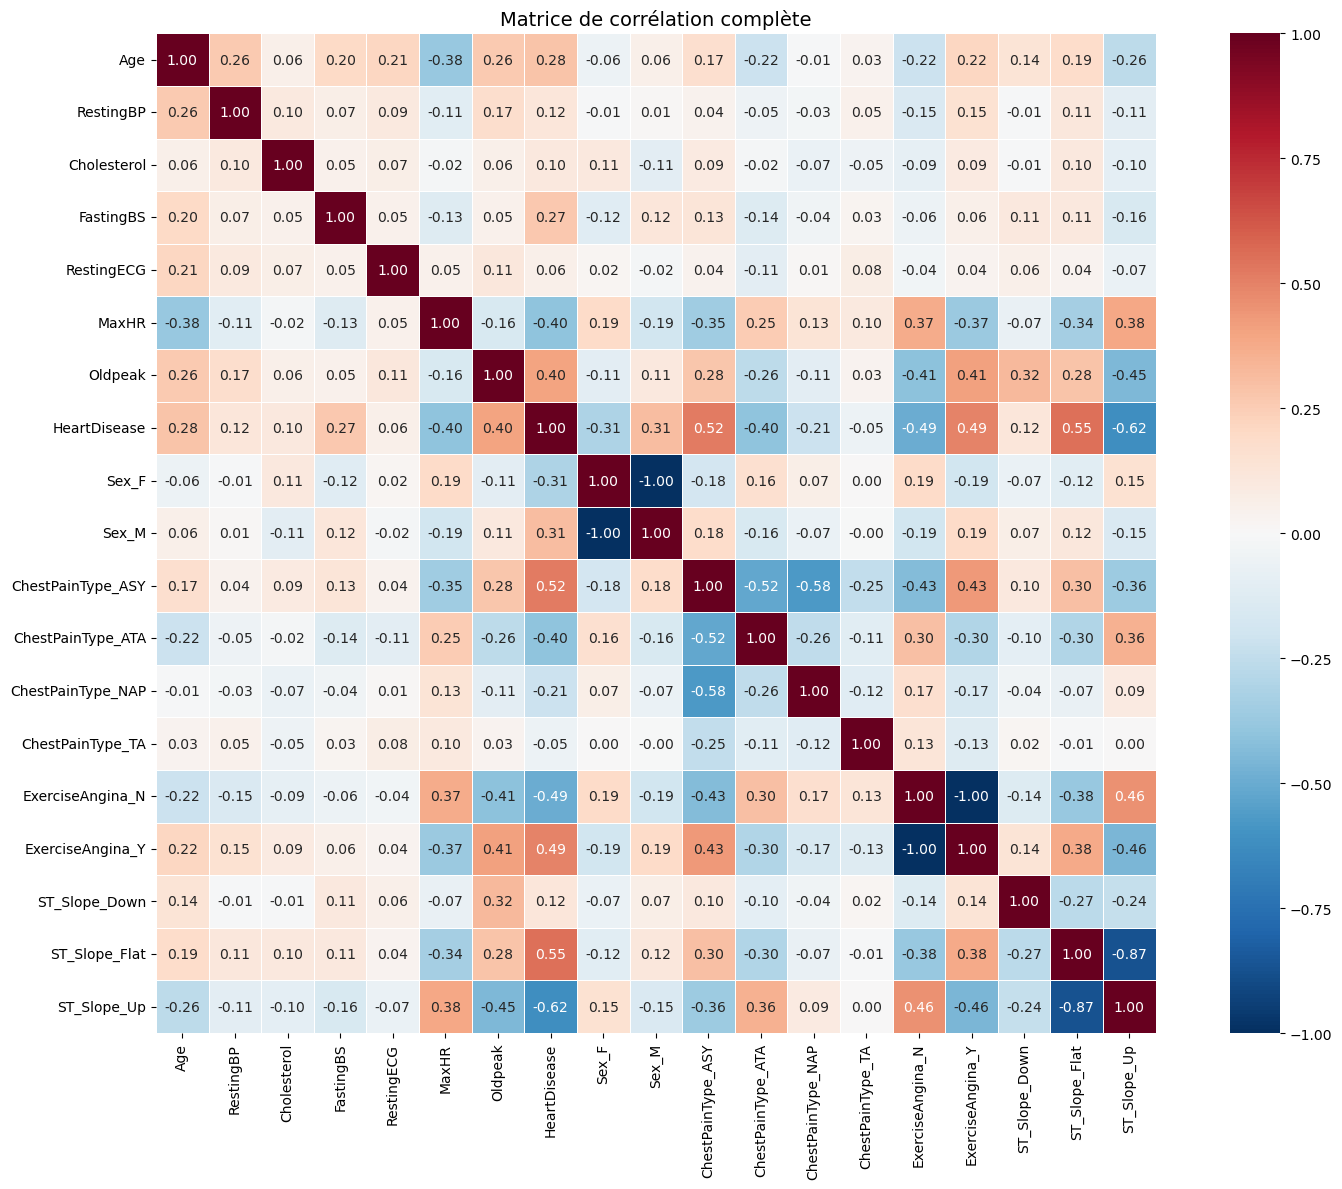

Corrélations avec HeartDisease :
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.117990
Cholesterol          0.103866
RestingECG           0.061011
ChestPainType_TA    -0.054790
ChestPainType_NAP   -0.212964
Sex_F               -0.305445
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ExerciseAngina_N    -0.494282
ST_Slope_Up         -0.622164


In [11]:
# Encoder les catégorielles ET garder les numériques ensemble
df_encoded = pd.get_dummies(df, drop_first=False)

# Remplacer les 0 par NaN avant de calculer la corrélation
# (pour ne pas fausser avec les valeurs aberrantes)
df_encoded['Cholesterol'] = df_encoded['Cholesterol'].replace(0, float('nan'))
df_encoded['RestingBP'] = df_encoded['RestingBP'].replace(0, float('nan'))

plt.figure(figsize=(16, 12))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation complète', fontsize=14)
plt.tight_layout()
plt.show()

# Corrélations avec HeartDisease triées
print("Corrélations avec HeartDisease :")
print(corr['HeartDisease'].drop('HeartDisease').sort_values(ascending=False).to_string())

## Step 5 — Séparation Features (X) / Target (y)

On sépare les **11 features** (variables explicatives) de la **variable cible** `HeartDisease` (0 = sain, 1 = malade).

In [12]:
# Liste des colonnes que nous allons utiliser pour prédire
features_list = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
                 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina',
                 'Oldpeak', 'ST_Slope']

X = df.loc[:, features_list]
y = df.loc[:, 'HeartDisease']


## Step 6 — Split Train / Test

On coupe le dataset en **80% entraînement** et **20% test** avec `stratify=y` pour conserver les mêmes proportions de malades/sains.  
`random_state=0` assure la reproductibilité des résultats.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print(f"Données d'entraînement : {X_train.shape[0]} lignes\n")
print(f"Données de test : {X_test.shape[0]} lignes")


Données d'entraînement : 734 lignes

Données de test : 184 lignes


## Step 7 — Prétraitement des données

### 7.1 — Définition des groupes de colonnes

- **Numériques** (Age, RestingBP, Cholesterol, MaxHR, Oldpeak) : imputation médiane + standardisation
- **Catégorielles** (Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina, ST_Slope) : encodage One-Hot

In [14]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Colonnes catégorielles (mots/catégories)
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

### 7.2 — Création du pipeline de transformation

Le `ColumnTransformer` applique automatiquement le bon traitement à chaque groupe :
- **SimpleImputer(median)** : remplace les NaN par la médiane
- **StandardScaler** : centre et réduit les valeurs (moyenne=0, écart-type=1)
- **OneHotEncoder(drop='first')** : colonnes binaires, supprime la première pour éviter la multicolinéarité

In [15]:
# 1. Pipeline pour les nombres :
# - Imputer : remplace les NaN (nos anciens zéros) par la médiane.
# - Scaler  : met tous les nombres sur la même échelle.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# 2. Le moteur final qui assemble tout :
# - On applique le pipeline numérique aux colonnes numériques.
# - On encode les catégories en chiffres (0/1) avec OneHotEncoder.
feature_encoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,           numeric_features),
        ('cat', OneHotEncoder(drop=None),   categorical_features)
    ],
    verbose_feature_names_out=False
)

print("✅ Le moteur de transformation (feature_encoder) est prêt !")


✅ Le moteur de transformation (feature_encoder) est prêt !


### 7.3 — Application de la transformation

**Point crucial** : `fit_transform()` sur le train set uniquement, puis `transform()` sur le test set.  
Cela évite le **data leakage** : le modèle ne doit jamais "voir" les données de test pendant l'entraînement.

In [16]:
# On ne touche plus à X_train après ça
X_train_transformed = feature_encoder.fit_transform(X_train)

# 2. On transforme le Test (X_test_transformed existe déjà dans ton code, c'est parfait)
X_test_transformed = feature_encoder.transform(X_test)

print("✅ Données transformées dans de nouvelles variables !")


✅ Données transformées dans de nouvelles variables !


## Step 8 — Modèle 1 : Régression Logistique

La Régression Logistique est notre **baseline**. Elle calcule la probabilité qu'un patient soit malade (entre 0 et 1). Au-dessus de 0.5 → classé "malade".

### 8.1 — Entraînement

In [17]:
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train_transformed, y_train)

print("✅ Le modèle a fini son apprentissage.")


✅ Le modèle a fini son apprentissage.


### 8.2 — Prédictions

In [18]:
y_train_pred = classifier.predict(X_train_transformed)

# Sur les données de test (l'examen final)
y_test_pred = classifier.predict(X_test_transformed)

print("✅ Prédictions terminées.\n")
print("#### 5 premières prédictions sur le TEST set ####\n")
print(y_test_pred[0:5])

✅ Prédictions terminées.

#### 5 premières prédictions sur le TEST set ####

[1 1 0 1 1]


### 8.3 — Évaluation : Accuracy

L'**accuracy** mesure le pourcentage de prédictions correctes.

In [19]:
# Calcul des scores
score_train = classifier.score(X_train_transformed, y_train)
score_test = classifier.score(X_test_transformed, y_test)

print(f"✅ Score d'Accuracy (Train) : {score_train:.3f}")
print(f"✅ Score d'Accuracy (Test)  : {score_test:.3f}")

✅ Score d'Accuracy (Train) : 0.864
✅ Score d'Accuracy (Test)  : 0.859


### 8.4 — Matrice de confusion (Train set)

La matrice détaille les 4 cas : Vrais Positifs, Vrais Négatifs, Faux Positifs et Faux Négatifs.  
En médecine, les **Faux Négatifs** (malades non détectés) sont les plus dangereux.

--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---

Accuracy sur le Train set : 0.864



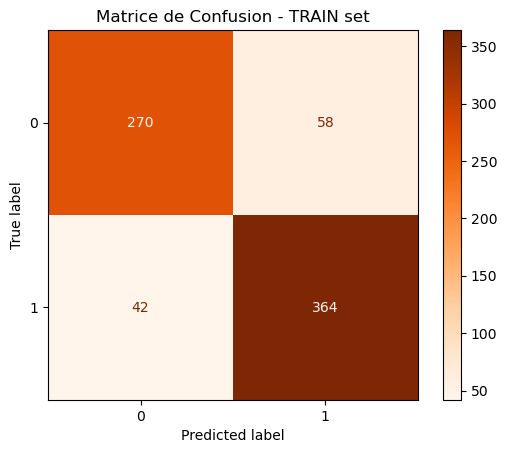

In [20]:
### MATRICE DE CONFUSION - TRAIN SET ###

print("--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---\n")

score_train = classifier.score(X_train_transformed, y_train)
print(f"Accuracy sur le Train set : {round(score_train, 3)}\n")

ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_train_transformed,
    y_train,
    cmap=plt.cm.Oranges
)
plt.title("Matrice de Confusion - TRAIN set")
plt.show()


### 8.5 — Matrice de confusion (Test set)

--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---

Accuracy sur le Test set : 0.859



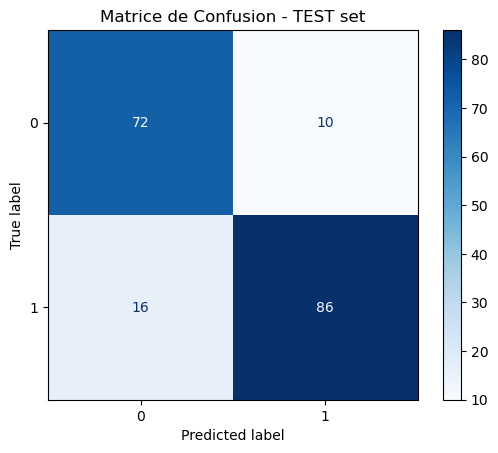

In [21]:
### MATRICE DE CONFUSION - TEST SET ###

print("--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---\n")

score_test = classifier.score(X_test_transformed, y_test)
print(f"Accuracy sur le Test set : {round(score_test, 3)}\n")

ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test_transformed,
    y_test,
    cmap=plt.cm.Blues
)
plt.title("Matrice de Confusion - TEST set")
plt.show()


### 8.6 — Coefficients de la Régression Logistique

Chaque coefficient = le **poids** d'une variable sur la prédiction :
- **Positif** → augmente la probabilité de maladie
- **Négatif** → diminue la probabilité
- Plus la valeur absolue est grande, plus la variable est influente

In [22]:
noms_variables = feature_encoder.get_feature_names_out()
poids          = classifier.coef_[0]

importance_df = pd.DataFrame({
    'Variable'   : noms_variables,
    'Coefficient': poids
})

importance_df = importance_df.sort_values(by='Coefficient', ascending=False)

print("--- Importance des variables ---\n")
display(importance_df)


--- Importance des variables ---



,Variable,Coefficient
7,ChestPainType_ASY,1.173460
19,ST_Slope_Flat,1.057247
6,Sex_M,0.717669
12,FastingBS_1,0.547236
17,ExerciseAngina_Y,0.375974
4,Oldpeak,0.348896
0,Age,0.151160
2,Cholesterol,0.123137
1,RestingBP,0.094801
15,RestingECG_2,0.036821


### 8.7 — Visualisation des coefficients

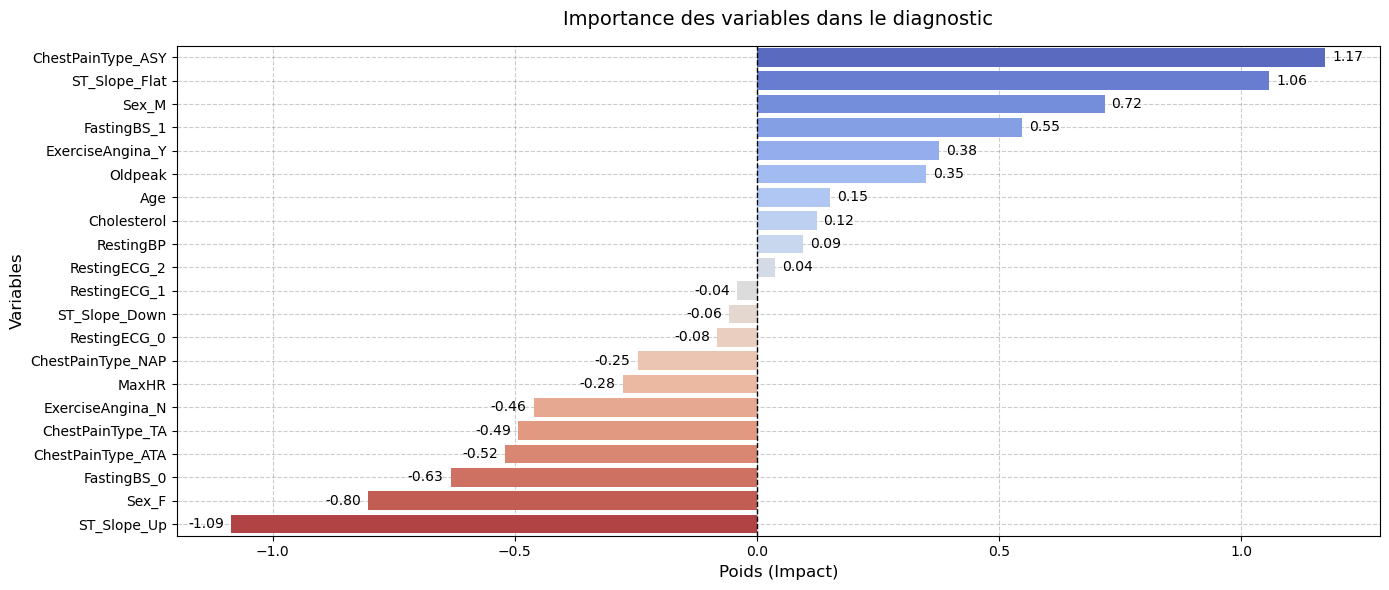

In [23]:
noms_variables = feature_encoder.get_feature_names_out()
poids          = classifier.coef_[0]

importance_df = pd.DataFrame({
    'Variable'   : noms_variables,
    'Coefficient': poids
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x='Coefficient', y='Variable',
    data=importance_df,
    palette='coolwarm', hue='Variable', legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

ax.set_axisbelow(True)
plt.grid(axis='both', linestyle='--', alpha=0.4, color='gray')
plt.title("Importance des variables dans le diagnostic", fontsize=14, pad=15)
plt.xlabel("Poids (Impact)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


## Step 9 — Modèle 2 : Arbre de Décision

L'arbre de décision pose des **questions binaires** sur les variables pour arriver à une prédiction. Ici, on l'entraîne **sans contrainte de profondeur** : l'arbre mémorise chaque patient → **overfitting attendu**.

### 9.1 — Entraînement (sans contrainte)

In [24]:
# Sans contrainte de profondeur: l'arbre mémorise chaque patient du train

classifier_dt = DecisionTreeClassifier(random_state=0, min_samples_leaf=1)
classifier_dt.fit(X_train_transformed, y_train)

print("✅ Le modèle a fini son apprentissage")


✅ Le modèle a fini son apprentissage


### 9.2 — Prédictions

In [25]:
y_train_pred_dt = classifier_dt.predict(X_train_transformed)

# Sur les données de test (l'examen final)
y_test_pred_dt = classifier_dt.predict(X_test_transformed)

print("Aperçu des prédictions (train) :", y_train_pred_dt[0:5])
print("Aperçu des prédictions (test)  :", y_test_pred_dt[0:5])

Aperçu des prédictions (train) : [0 0 1 1 1]
Aperçu des prédictions (test)  : [1 1 0 1 1]


### 9.3 — Évaluation : Accuracy

Un **écart Train/Test élevé** = signe classique de l'overfitting : le modèle a "appris par coeur" au lieu de généraliser.

In [26]:
score_train_dt = classifier_dt.score(X_train_transformed, y_train)
score_test_dt  = classifier_dt.score(X_test_transformed, y_test)

print(f"✅ Score d'Accuracy (Train) : {score_train_dt:.3f}")
print(f"✅ Score d'Accuracy (Test)  : {score_test_dt:.3f}")

# Un écart Train/Test élevé = signe d'overfitting

print(f"\nÉcart Train-Test : {score_train_dt - score_test_dt:.3f}")

✅ Score d'Accuracy (Train) : 1.000
✅ Score d'Accuracy (Test)  : 0.772

Écart Train-Test : 0.228


### 9.4 — Matrices de confusion

--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---



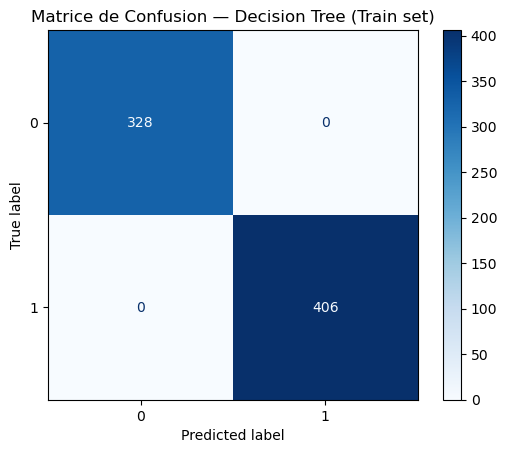

--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---



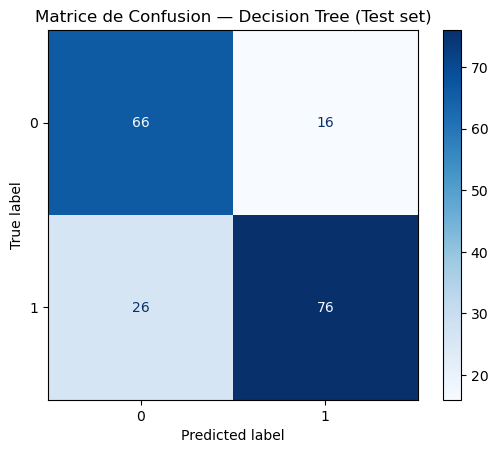

In [27]:
### MATRICE DE CONFUSION - TRAIN SET ###
print("--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---\n")

ConfusionMatrixDisplay.from_estimator(
    classifier_dt, X_train_transformed, y_train, cmap=plt.cm.Blues
)
plt.title("Matrice de Confusion — Decision Tree (Train set)")
plt.show()

### MATRICE DE CONFUSION - TEST SET ###
print("--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---\n")

ConfusionMatrixDisplay.from_estimator(
    classifier_dt, X_test_transformed, y_test, cmap=plt.cm.Blues
)
plt.title("Matrice de Confusion — Decision Tree (Test set)")
plt.show()
# En modifiant le min_samples_leaf à 10 au lieu de la valeur par defaut qui est 1, nous remarquons que les Vrais Negatifs augmentent et les Faux Positifs diminuent.
# Pas d'impact sur les Faux Negatifs et les Vrais Positifs.
# On a la possibilité de réduire l'overfitting en augmentant cette valeur.


### 9.5 — Rapport de classification

- **Precision** : parmi les prédits malades, combien le sont vraiment ?
- **Recall** : parmi les vrais malades, combien ont été détectés ? (priorité médicale)
- **F1-Score** : moyenne harmonique Precision / Recall

In [28]:
# Le classification_report donne pour chaque classe (0=sain, 1=malade) :
# - Precision : parmi les patients prédits malades, combien le sont vraiment ?
# - Recall    : parmi les vrais malades, combien on a détectés ? (priorité médicale !)
# - F1-Score  : moyenne harmonique Precision/Recall

print("--- Rapport de Classification (Test Set) ---\n")
print(classification_report(y_test, y_test_pred_dt, target_names=['Pas de maladie (0)', 'Maladie (1)']))


--- Rapport de Classification (Test Set) ---

                    precision    recall  f1-score   support

Pas de maladie (0)       0.72      0.80      0.76        82
       Maladie (1)       0.83      0.75      0.78       102

          accuracy                           0.77       184
         macro avg       0.77      0.77      0.77       184
      weighted avg       0.78      0.77      0.77       184



### 9.6 — Importance des variables (Decision Tree)

In [29]:
# Après transformation, les colonnes catégorielles sont éclatées
# (ex: Sex → Sex_M, Sex_F). On récupère les vrais noms avec get_feature_names_out().

feature_importance_dt = pd.DataFrame({
    "feature_names": feature_encoder.get_feature_names_out(),
    "coefficient"  : classifier_dt.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(by="coefficient", ascending=False)

print(feature_importance_dt)


        feature_names  coefficient
20        ST_Slope_Up     0.385830
3               MaxHR     0.108076
7   ChestPainType_ASY     0.096651
4             Oldpeak     0.084489
0                 Age     0.071867
1           RestingBP     0.070556
2         Cholesterol     0.058446
6               Sex_M     0.039782
17   ExerciseAngina_Y     0.018051
11        FastingBS_0     0.010372
12        FastingBS_1     0.009458
5               Sex_F     0.008268
14       RestingECG_1     0.006931
8   ChestPainType_ATA     0.005739
15       RestingECG_2     0.005512
18      ST_Slope_Down     0.005291
10   ChestPainType_TA     0.004823
9   ChestPainType_NAP     0.004409
13       RestingECG_0     0.002756
16   ExerciseAngina_N     0.002692
19      ST_Slope_Flat     0.000000


## Step 10 — Modèle 3 : Random Forest

Le Random Forest combine **plusieurs arbres de décision** entraînés sur des sous-ensembles aléatoires. Chaque arbre vote → le résultat = la majorité → réduit l'overfitting.

### 10.1 — Recherche du nombre optimal d'arbres

On teste de 100 à 2500 arbres pour trouver le meilleur compromis.

In [30]:
# Le Random Forest combine plusieurs arbres de décision entraînés sur des
# sous-ensembles aléatoires des données.
# Chaque arbre vote → le résultat final est la majorité des votes.

# 1. Recherche du n_estimators optimal
n_options        = [100, 200, 500, 1000, 1500, 2000, 2500]
scores_test_list = []

print("🔍 Recherche du n_estimators optimal...\n")
for n in n_options:
    temp_rf = RandomForestClassifier(n_estimators=n, random_state=0)
    temp_rf.fit(X_train_transformed, y_train)
    score_n = temp_rf.score(X_test_transformed, y_test)
    scores_test_list.append(score_n)
    print(f"   - Pour {n} arbres : Accuracy Test = {score_n:.4f}")

# 2. Meilleur réglage
meilleur_n = n_options[scores_test_list.index(max(scores_test_list))]
print(f"\n🏆 Le meilleur n_estimators retenu est : {meilleur_n}\n")

# 3. Entraînement du modèle final
print("Entraînement du modèle final en cours...\n")
classifier_rf = RandomForestClassifier(n_estimators=meilleur_n, min_samples_leaf=1, random_state=0)
classifier_rf.fit(X_train_transformed, y_train)

print("✅ Le modèle a fini son apprentissage")


🔍 Recherche du n_estimators optimal...

   - Pour 100 arbres : Accuracy Test = 0.8533
   - Pour 200 arbres : Accuracy Test = 0.8804
   - Pour 500 arbres : Accuracy Test = 0.8750
   - Pour 1000 arbres : Accuracy Test = 0.8804
   - Pour 1500 arbres : Accuracy Test = 0.8750
   - Pour 2000 arbres : Accuracy Test = 0.8750
   - Pour 2500 arbres : Accuracy Test = 0.8750

🏆 Le meilleur n_estimators retenu est : 200

Entraînement du modèle final en cours...

✅ Le modèle a fini son apprentissage


### 10.2 — Prédictions

In [31]:
y_train_pred_rf = classifier_rf.predict(X_train_transformed)

# Sur les données de test (l'examen final)
y_test_pred_rf = classifier_rf.predict(X_test_transformed)

print("Aperçu des prédictions (train) :", y_train_pred_rf[0:5])
print("Aperçu des prédictions (test)  :", y_test_pred_rf[0:5])

Aperçu des prédictions (train) : [0 0 1 1 1]
Aperçu des prédictions (test)  : [1 1 0 1 1]


### 10.3 — Évaluation : Accuracy

Train=100% est normal pour un Random Forest. Ce qui compte, c'est le **score Test** = capacité de généralisation.

In [32]:
score_train_rf = classifier_rf.score(X_train_transformed, y_train)
score_test_rf  = classifier_rf.score(X_test_transformed, y_test)

print(f"✅ Score d'Accuracy (Train) : {score_train_rf:.3f}")
print(f"✅ Score d'Accuracy (Test)  : {score_test_rf:.3f}")

# Train=100% est attendu pour un Random Forest (chaque arbre mémorise son sous-ensemble)
# Ce qui compte c'est le Test score → 88% = meilleur modèle
print(f"\nÉcart Train-Test : {score_train_rf - score_test_rf:.3f}")
if score_train_rf - score_test_rf > 0.1:
    print("⚠️ Attention : écart Train-Test élevé, signe possible d'overfitting.")
else:
    print("✅ Pas d'overfitting détecté.")

✅ Score d'Accuracy (Train) : 1.000
✅ Score d'Accuracy (Test)  : 0.880

Écart Train-Test : 0.120
⚠️ Attention : écart Train-Test élevé, signe possible d'overfitting.


### 10.4 — Matrices de confusion

--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---



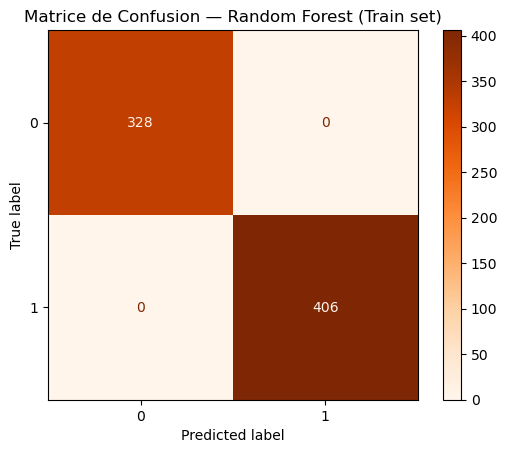

--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---



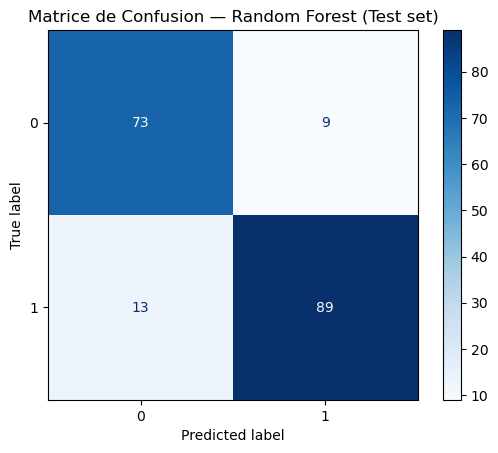

In [33]:
### MATRICE DE CONFUSION - TRAIN SET ###
print("--- 1. RÉSULTATS SUR L'ENTRAÎNEMENT (TRAIN SET) ---\n")

ConfusionMatrixDisplay.from_estimator(
    classifier_rf, X_train_transformed, y_train, cmap=plt.cm.Oranges
)
plt.title("Matrice de Confusion — Random Forest (Train set)")
plt.show()

### MATRICE DE CONFUSION - TEST SET ###
print("--- 2. RÉSULTATS SUR LE TEST (EXAMEN FINAL) ---\n")

ConfusionMatrixDisplay.from_estimator(
    classifier_rf, X_test_transformed, y_test, cmap=plt.cm.Blues
)
plt.title("Matrice de Confusion — Random Forest (Test set)")
plt.show()


### 10.5 — Rapport de classification

In [34]:
# Recall sur la classe 1 (Maladie) = priorité médicale absolue
# → On veut détecter un maximum de vrais malades

print("--- Rapport de Classification (Test Set) ---\n")
print(classification_report(y_test, y_test_pred_rf, target_names=['Pas de maladie (0)', 'Maladie (1)']))


--- Rapport de Classification (Test Set) ---

                    precision    recall  f1-score   support

Pas de maladie (0)       0.85      0.89      0.87        82
       Maladie (1)       0.91      0.87      0.89       102

          accuracy                           0.88       184
         macro avg       0.88      0.88      0.88       184
      weighted avg       0.88      0.88      0.88       184



### 10.6 — Importance des variables (Gini)

L'importance Gini mesure la contribution de chaque variable à la séparation des classes dans les arbres.

             Variable  Importance
20        ST_Slope_Up    0.119884
19      ST_Slope_Flat    0.104909
3               MaxHR    0.103073
4             Oldpeak    0.095898
7   ChestPainType_ASY    0.090174
2         Cholesterol    0.075269
0                 Age    0.072869
1           RestingBP    0.069975
16   ExerciseAngina_N    0.056833
17   ExerciseAngina_Y    0.051218
6               Sex_M    0.023751
5               Sex_F    0.021687
12        FastingBS_1    0.020336
8   ChestPainType_ATA    0.017662
11        FastingBS_0    0.016108
9   ChestPainType_NAP    0.013135
13       RestingECG_0    0.012809
15       RestingECG_2    0.012586
14       RestingECG_1    0.009426
18      ST_Slope_Down    0.006692
10   ChestPainType_TA    0.005705


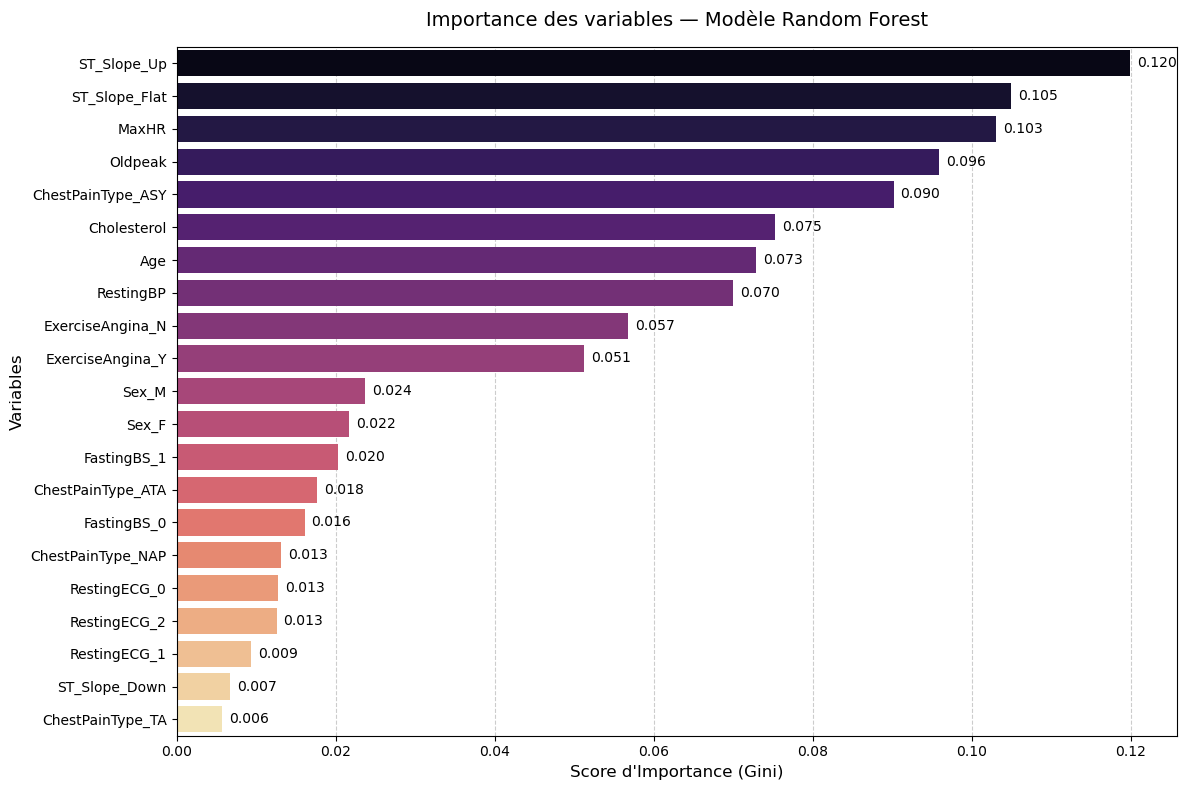

In [35]:
noms_bruts   = feature_encoder.get_feature_names_out()
noms_propres = [name.split('__')[-1] for name in noms_bruts]

feature_importance_rf = pd.DataFrame({
    "Variable"  : noms_propres,
    "Importance": classifier_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance_rf)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', y='Variable',
    data=feature_importance_rf,
    palette='magma', hue='Variable', legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
plt.title("Importance des variables — Modèle Random Forest", fontsize=14, pad=15)
plt.xlabel("Score d'Importance (Gini)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.tight_layout()
plt.show()


## Step 11 — Comparaison finale des 3 modèles

On compare les scores Train et Test pour identifier le meilleur modèle et les cas d'overfitting.

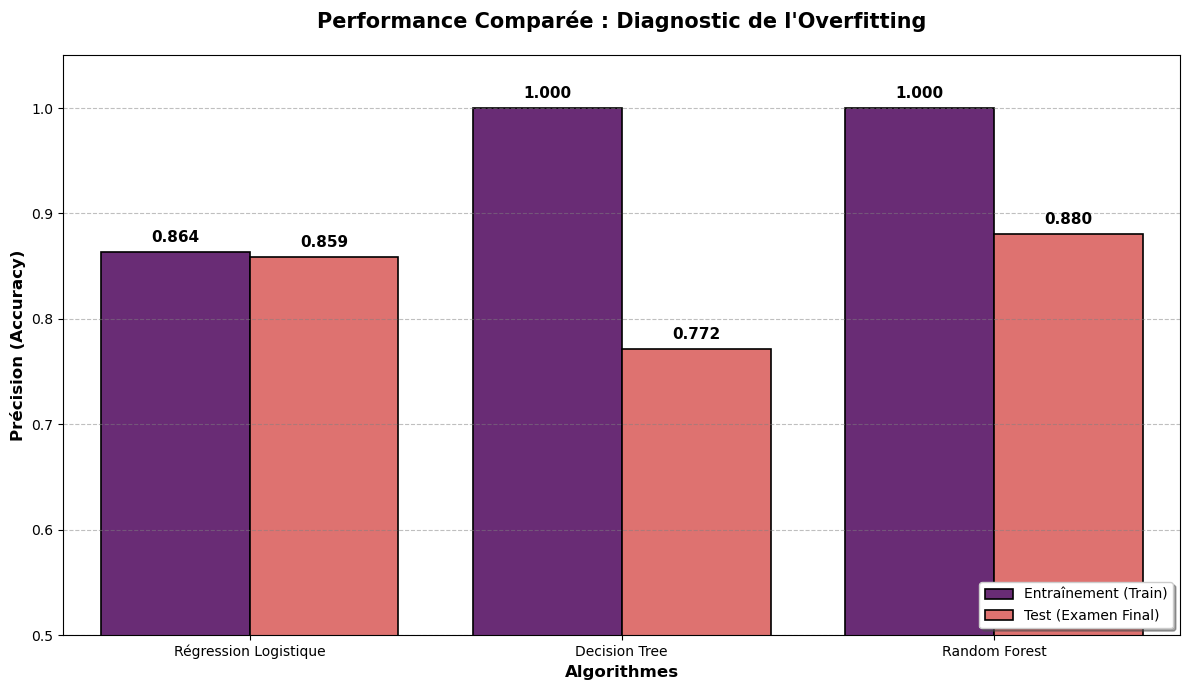

🚀 VERDICT : Le modèle le plus robuste est le Random Forest.


In [36]:
modeles      = ['Régression Logistique', 'Decision Tree', 'Random Forest']
scores_train = [
    classifier.score(X_train_transformed, y_train),
    classifier_dt.score(X_train_transformed, y_train),
    classifier_rf.score(X_train_transformed, y_train)
]
scores_test = [
    classifier.score(X_test_transformed, y_test),
    classifier_dt.score(X_test_transformed, y_test),
    classifier_rf.score(X_test_transformed, y_test)
]

df_comparaison = pd.DataFrame({
    'Modèle'          : modeles * 2,
    'Score Accuracy'  : scores_train + scores_test,
    'Type de Données' : ['Entraînement (Train)'] * 3 + ['Test (Examen Final)'] * 3
})

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Modèle', y='Score Accuracy', hue='Type de Données',
    data=df_comparaison, palette='magma', edgecolor='black', linewidth=1.2
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontweight='bold', fontsize=11)

plt.title("Performance Comparée : Diagnostic de l'Overfitting", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Précision (Accuracy)", fontsize=12, fontweight='bold')
plt.xlabel("Algorithmes", fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

meilleur_index = np.argmax(scores_test)
print(f"🚀 VERDICT : Le modèle le plus robuste est le {modeles[meilleur_index]}.")


## Step 12 — Analyse du seuil de décision

Par défaut, un patient est classé "malade" si la probabilité dépasse **0.5**.  
En médecine, on peut **baisser le seuil** (ex: 0.4) pour détecter plus de vrais malades, quitte à avoir plus de faux positifs.  
**Mieux vaut envoyer un patient sain faire des examens que de rater un malade.**

### 12.1 — Random Forest : seuil 0.4

In [37]:
probas    = classifier_rf.predict_proba(X_test_transformed)[:, 1]
y_pred_04 = (probas >= 0.4).astype(int)

cm = confusion_matrix(y_test, y_pred_04)
print("Seuil 0.4 :")
print(f"  Vrais négatifs  : {cm[0][0]}")
print(f"  Faux positifs   : {cm[0][1]}")
print(f"  Faux négatifs   : {cm[1][0]}")
print(f"  Vrais positifs  : {cm[1][1]}")
print()
print(classification_report(y_test, y_pred_04, target_names=['Sain (0)', 'Malade (1)']))


Seuil 0.4 :
  Vrais négatifs  : 67
  Faux positifs   : 15
  Faux négatifs   : 9
  Vrais positifs  : 93

              precision    recall  f1-score   support

    Sain (0)       0.88      0.82      0.85        82
  Malade (1)       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



### 12.2 — Comparaison Recall seuil 0.5 vs 0.4 (Random Forest)

In [38]:
probas = classifier_rf.predict_proba(X_test_transformed)[:, 1]

# Seuil 0.5 (défaut)
y_pred_05 = (probas >= 0.5).astype(int)
recall_05 = recall_score(y_test, y_pred_05)

# Seuil 0.4 (plus prudent)
y_pred_04 = (probas >= 0.4).astype(int)
recall_04 = recall_score(y_test, y_pred_04)

print(f"Recall seuil 0.5 : {recall_05:.4f}  ({recall_05*100:.1f}%)")
print(f"Recall seuil 0.4 : {recall_04:.4f}  ({recall_04*100:.1f}%)")


Recall seuil 0.5 : 0.8725  (87.3%)
Recall seuil 0.4 : 0.9118  (91.2%)


### 12.3 — Comparaison Recall seuil 0.5 vs 0.4 (Régression Logistique)

In [39]:
probas_lr = classifier.predict_proba(X_test_transformed)[:, 1]

for seuil in [0.5, 0.4]:
    y_pred   = (probas_lr >= seuil).astype(int)
    cm       = confusion_matrix(y_test, y_pred)
    recall   = recall_score(y_test, y_pred)
    accuracy = (cm[0][0] + cm[1][1]) / cm.sum()
    print(f"Seuil {seuil} :")
    print(f"  Accuracy     : {accuracy:.1%}")
    print(f"  Recall       : {recall:.1%}")
    print(f"  Faux négatifs: {cm[1][0]}")
    print(f"  Faux positifs: {cm[0][1]}")
    print()


Seuil 0.5 :
  Accuracy     : 85.9%
  Recall       : 84.3%
  Faux négatifs: 16
  Faux positifs: 10

Seuil 0.4 :
  Accuracy     : 85.9%
  Recall       : 87.3%
  Faux négatifs: 13
  Faux positifs: 13



## Step 13 — Prédiction sur un nouveau patient

On met le modèle Random Forest en action sur un nouveau patient pour voir s'il est **malade ou sain**.

In [40]:
# On crée le patient comme une ligne de notre dataset
nouveau_patient = pd.DataFrame([{
    'Age': 58,
    'Sex': 'M',
    'ChestPainType': 'ASY',
    'RestingBP': 145,
    'Cholesterol': 280,
    'FastingBS': 1,
    'RestingECG': 1,
    'MaxHR': 110,
    'ExerciseAngina': 'Y',
    'Oldpeak': 2.5,
    'ST_Slope': 'Flat'
}])

nouveau_patient

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,58,M,ASY,145,280,1,1,110,Y,2.5,Flat


In [41]:
# On transforme le patient avec le même feature_encoder
patient_transformed = feature_encoder.transform(nouveau_patient)

# Prédiction
prediction = classifier_rf.predict(patient_transformed)
probas_patient = classifier_rf.predict_proba(patient_transformed)

print("Probabilité d'être sain   :", round(probas_patient[0][0] * 100, 1), "%")
print("Probabilité d'être malade :", round(probas_patient[0][1] * 100, 1), "%")
print()

if prediction[0] == 1:
    print("Résultat : MALADE")
else:
    print("Résultat : SAIN")

Probabilité d'être sain   : 1.0 %
Probabilité d'être malade : 99.0 %

Résultat : MALADE


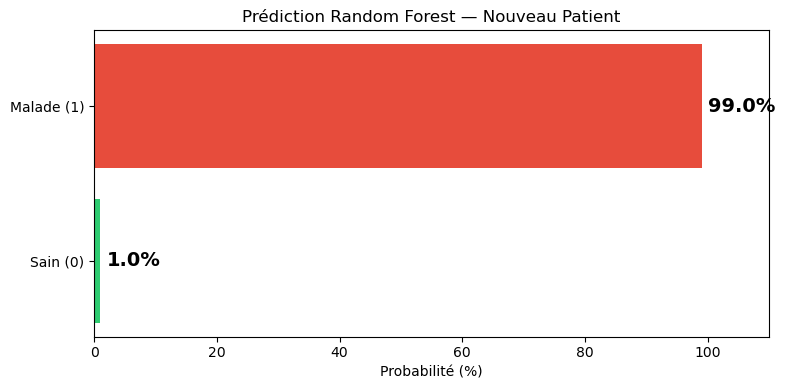

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

categories = ['Sain (0)', 'Malade (1)']
couleurs = ['#2ecc71', '#e74c3c']
valeurs = [probas_patient[0][0] * 100, probas_patient[0][1] * 100]

ax.barh(categories, valeurs, color=couleurs)

for i, val in enumerate(valeurs):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=14, fontweight='bold')

ax.set_xlim(0, 110)
ax.set_xlabel('Probabilité (%)')
ax.set_title('Prédiction Random Forest — Nouveau Patient')

plt.tight_layout()
plt.show()

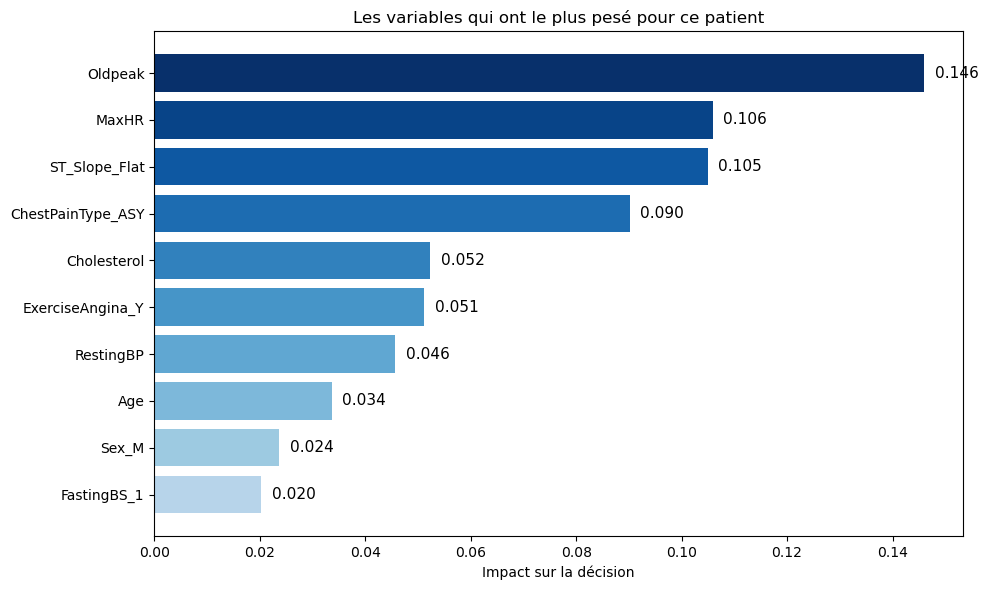

In [43]:
# Quelles variables ont le plus pesé pour ce patient ?

noms_bruts = feature_encoder.get_feature_names_out()
noms_propres = [name.split('__')[-1] for name in noms_bruts]

valeurs_patient = patient_transformed[0]
importances = classifier_rf.feature_importances_

impact = pd.DataFrame({
    'Variable': noms_propres,
    'Importance Gini': importances,
    'Valeur patient': valeurs_patient
})

impact['Impact'] = impact['Importance Gini'] * abs(impact['Valeur patient'])
impact = impact.sort_values('Impact', ascending=True)

top10 = impact.tail(10)

# Palette de couleurs : du clair (faible impact) au foncé (fort impact)
couleurs = plt.cm.Blues(np.linspace(0.3, 1, len(top10)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Variable'], top10['Impact'], color=couleurs)

for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=11)

ax.set_xlabel('Impact sur la décision')
ax.set_title('Les variables qui ont le plus pesé pour ce patient')

plt.tight_layout()
plt.show()